## **Exploratory Data Analysis**

### **Load Processed Dataset**

In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency, spearmanr

In [3]:
# Loading Dataset
df = pd.read_csv(r"../data/HR-Employee-Attrition_cleaned.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [4]:
ordinal_cols = [
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 
    'JobLevel', 'JobSatisfaction', 'PerformanceRating', 
    'RelationshipSatisfaction', 'WorkLifeBalance']

# Nominal categorical columns
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

# continuous numerical columns
num_cols = [col for col in df.select_dtypes(include=[np.number]).columns 
    if col not in ordinal_cols and col != 'Attrition']

# Numerical coding of target
df["Attrition_num"] = df["Attrition"].replace({"No" :0,"Yes":1})

### **Target Variable Analysis**
understanding the distribution of employee attrition

In [5]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [6]:
df["Attrition"].value_counts(normalize=True)*100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

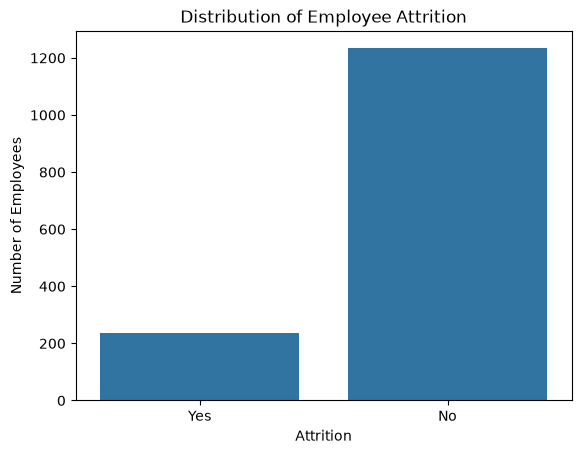

In [7]:
# Plotting the distribution
sns.countplot(data=df, x="Attrition")
plt.title("Distribution of Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

### **Inference**
- Approximately 84% of employee stayed, around 16% left the organization.
- at roughly 5:1 ratio this is significant imbalance, accuracy alone would be misleading metric.

### **Univariate Analysis**

In [8]:
# Numerical statistics for numerical columns
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0
MonthlyRate,1470.0,14313.103401,7117.786044,2094.0,8047.0,14235.5,20461.50,26999.0
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.00,9.0
PercentSalaryHike,1470.0,15.209524,3.659938,11.0,12.0,14.0,18.00,25.0
StockOptionLevel,1470.0,0.793878,0.852077,0.0,0.0,1.0,1.00,3.0
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.00,40.0


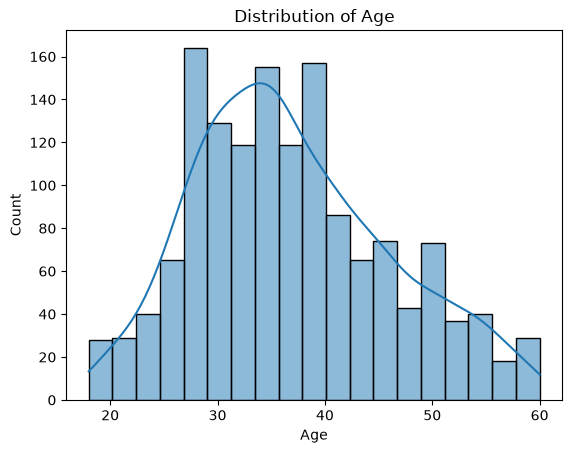

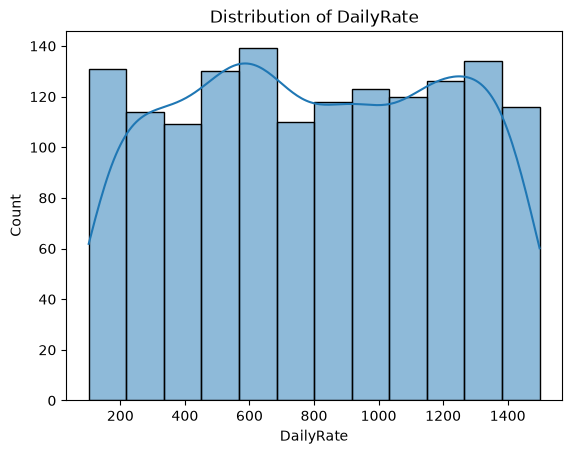

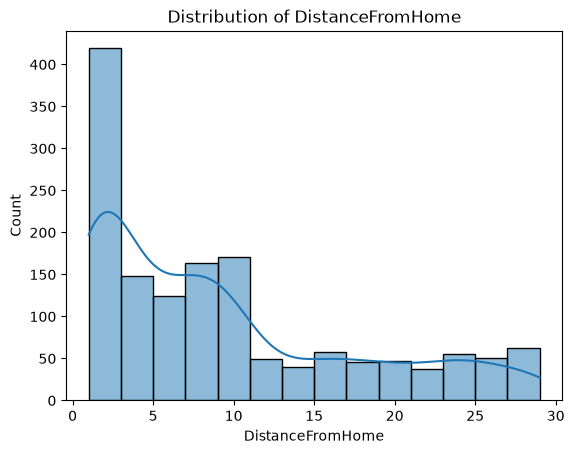

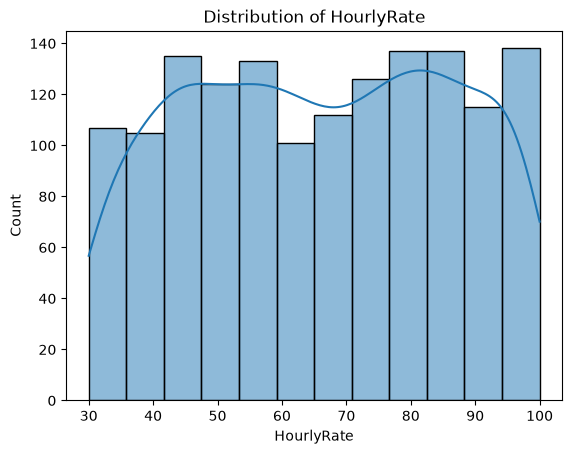

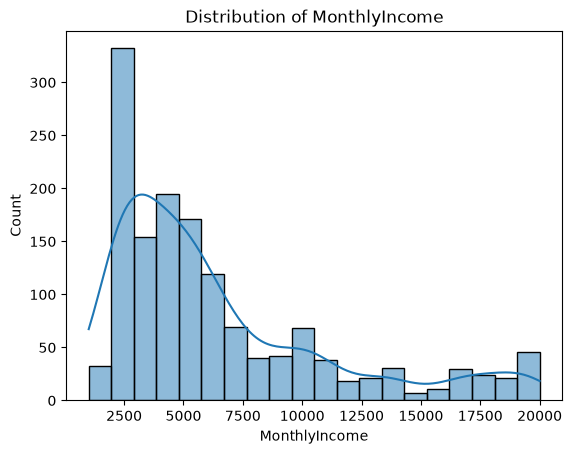

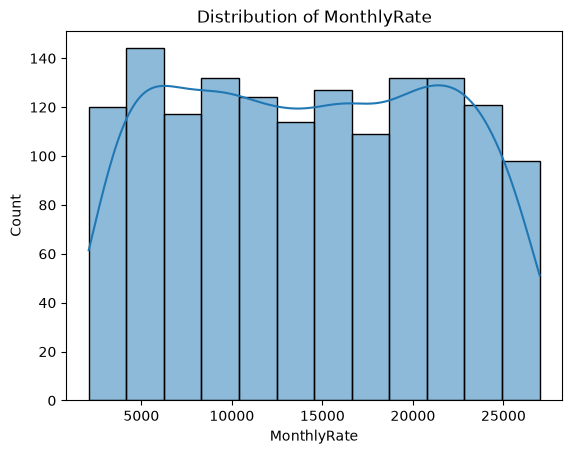

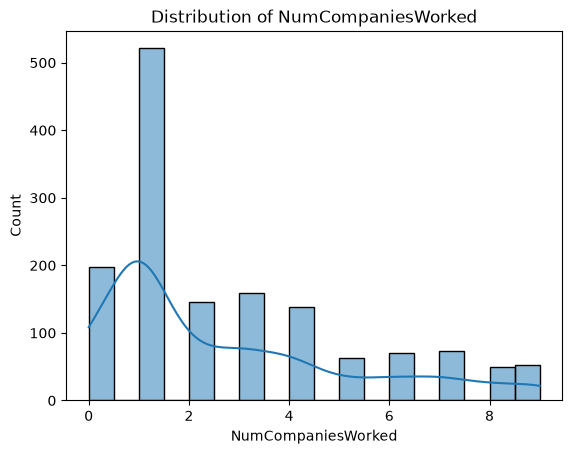

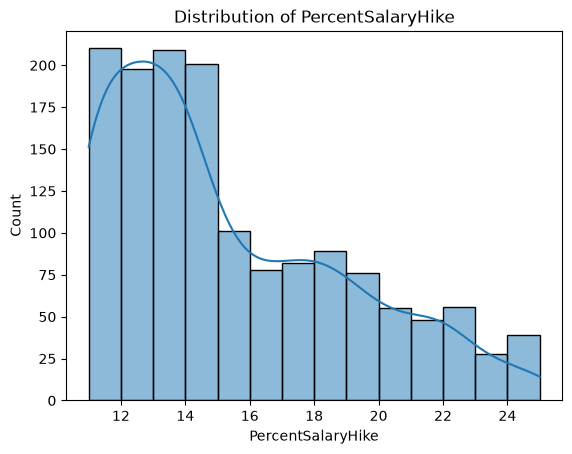

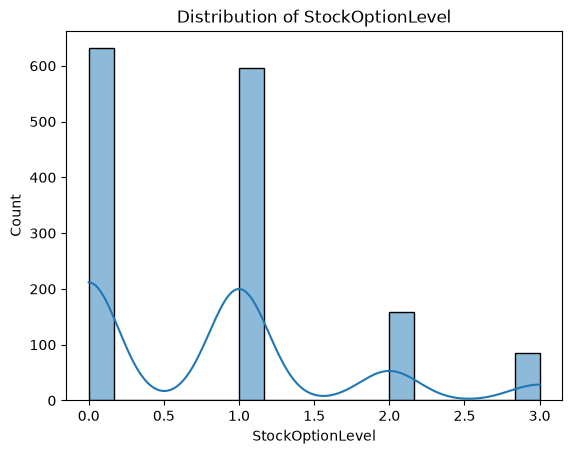

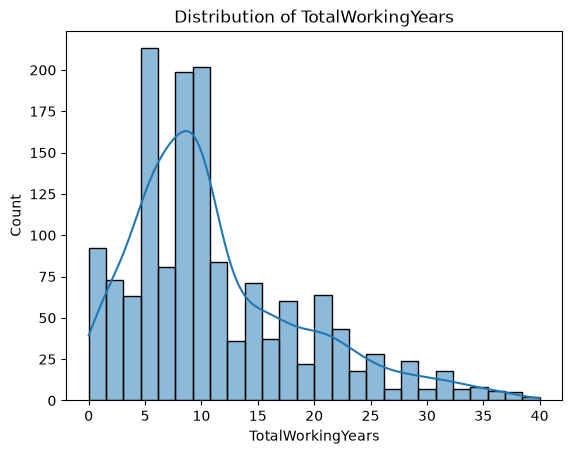

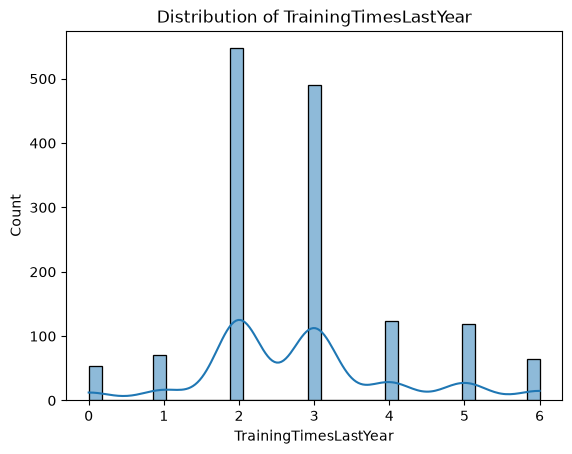

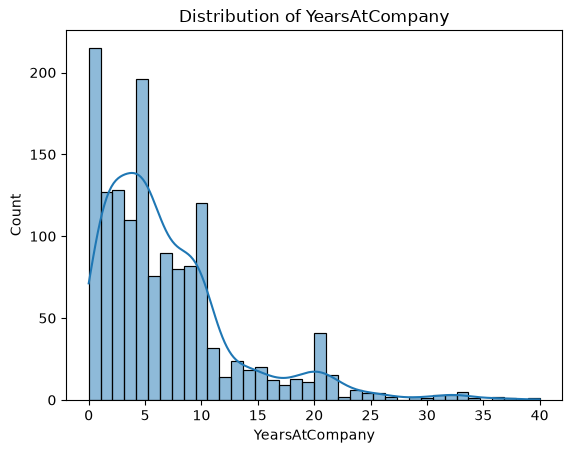

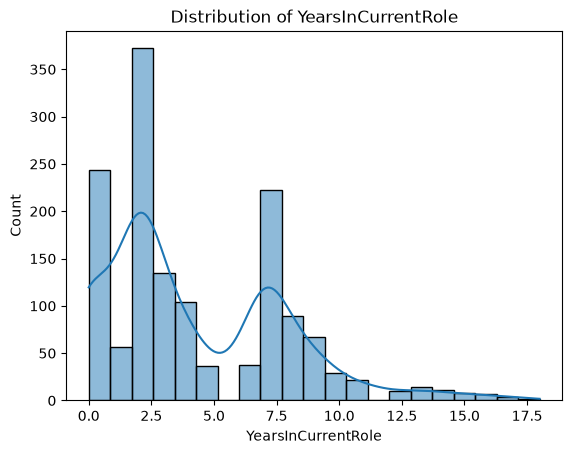

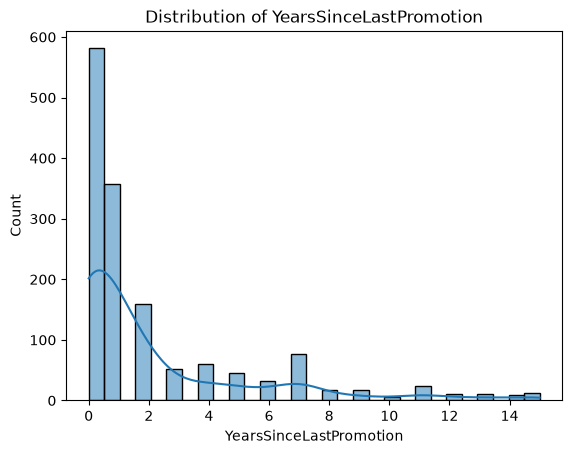

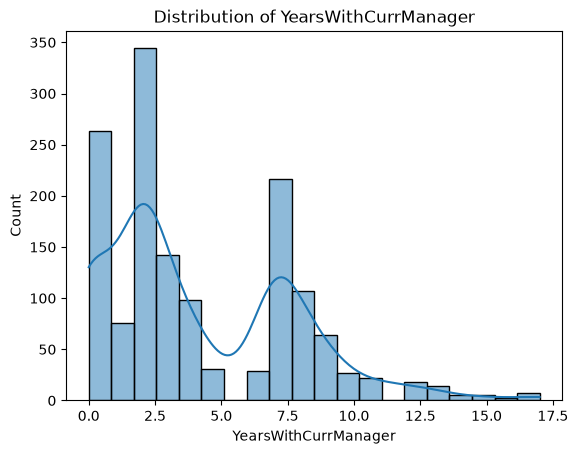

In [9]:
for col in num_cols:
    sns.histplot(data = df, x=df[col],kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [10]:
num_cols

['Age',
 'DailyRate',
 'DistanceFromHome',
 'HourlyRate',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

## Inferences from Univariate Analysis

### 1. `Age`, `MonthlyIncome`, `DailyRates`, `PercentSalaryHike`,`MonthlyRate`,`HourlyRate`
- **Age:** Roughly **normally distributed** with a peak around **30 to 40 years old**, indicating the large number of employees are in that age range.
- **MonthlyIncome:** Heavily **right-skewed**. The vast majority of employees fall into the lower-to-middle income brackets , with a long right tail indicating few  employees earn high salaries.
- **DailyRate, HourlyRate, & MonthlyRate:** Show rough **uniform distributions**,  indicating rates distribution varies uniformly with any peaks or clusturing.
- **PercentSalaryHike:** **Right-skewed**, with most employees receiving salary hikes between **11% and 15%**, and  hikes greater than 18% are rare.


### 2. `TotalWorkingYears`, `YearsAtCompany`, `YearsInCurrentRole`, etc.
- **TotalWorkingYears & YearsAtCompany:** Both are **right-skewed**, showing that most employees have under 10 years of total experience and fewer than 5 years at the current company.

- **`YearsSinceLastPromotion`:** A massive spike at **0 years**, indicating many employees either received a recent promotion or have never been promoted since joining.
- **`YearsInCurrentRole` & `YearsWithCurrManager`:** large number off employees falls in range **0 to 2 years**, indicating roles and managers changed recently for people.
- **NumCompaniesWorked:** Most employees have worked at **1 to 3 companies** previously, with a  peak at 1 company.


### 3. `DistanceFromHome`, `TrainingTimesLastYear`
- **DistanceFromHome:**  **right-skewed**. A large number of employees live close to the office.
- **TrainingTimesLastYear:** centered around **2 to 3 training sessions** per year.

## **Bivariate Analysis**


## **Numerical Features vs. Attrition**


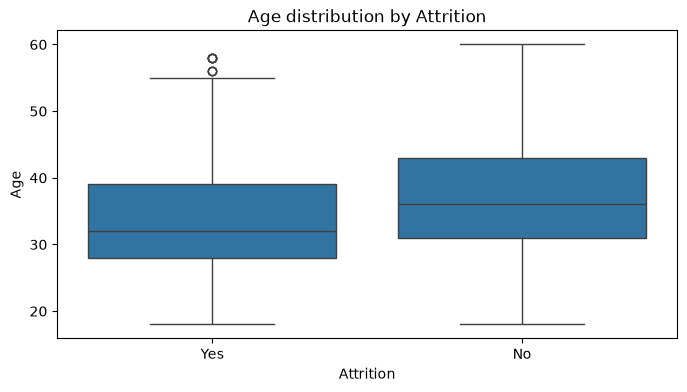

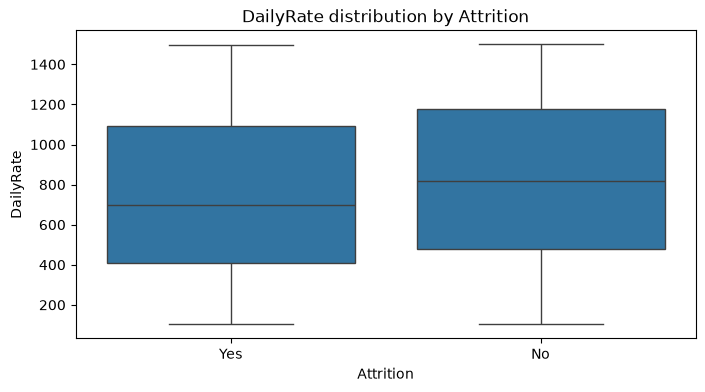

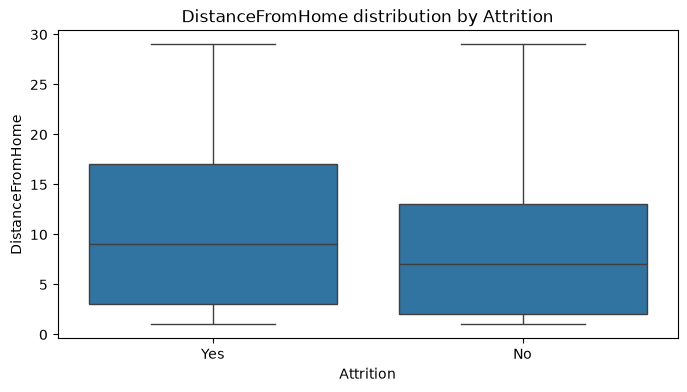

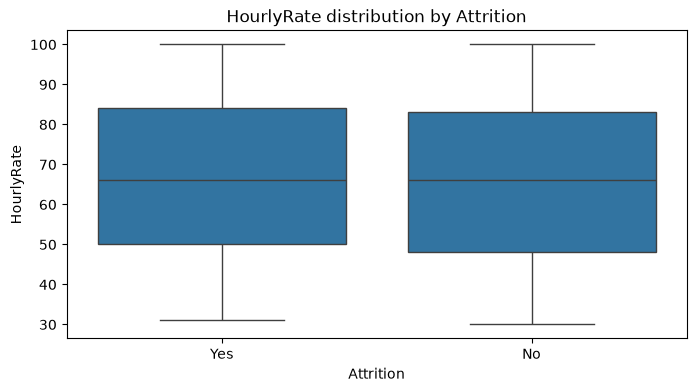

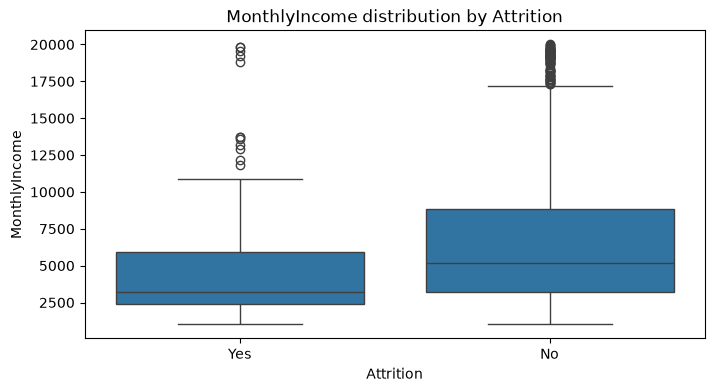

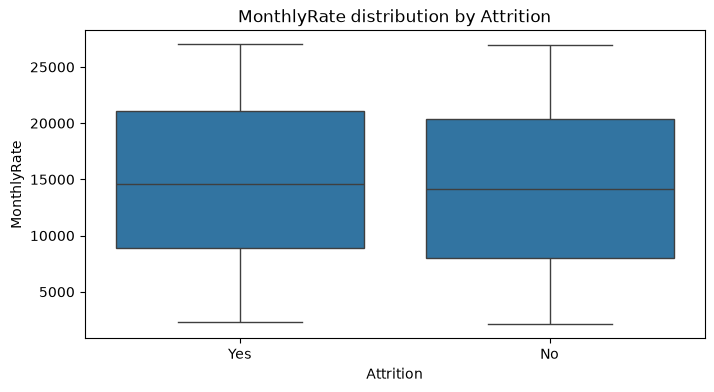

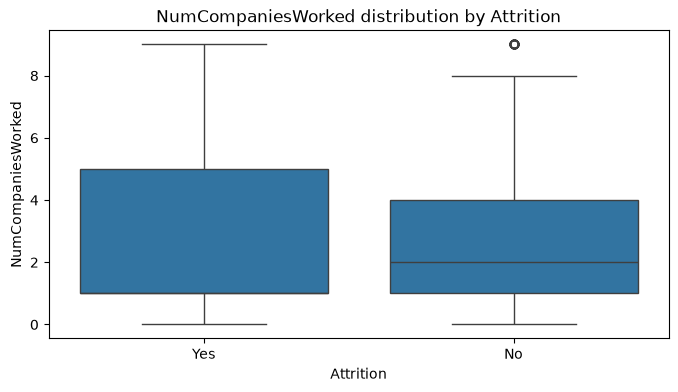

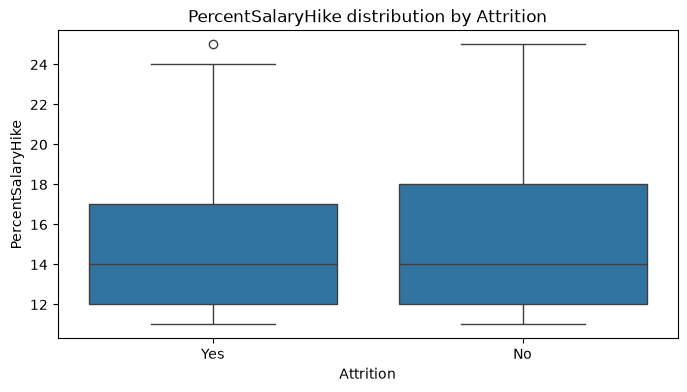

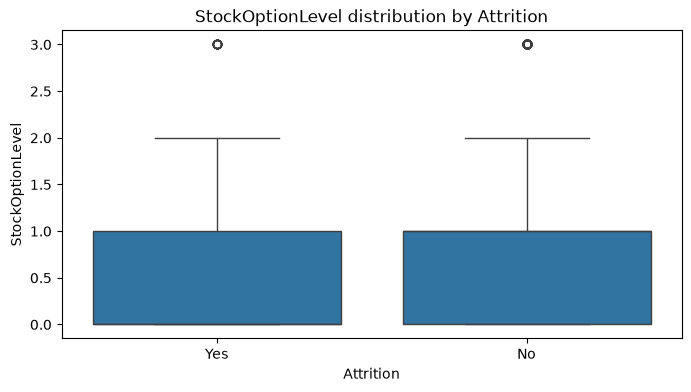

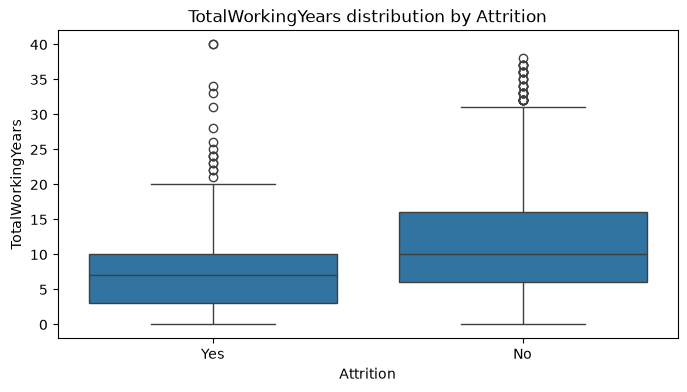

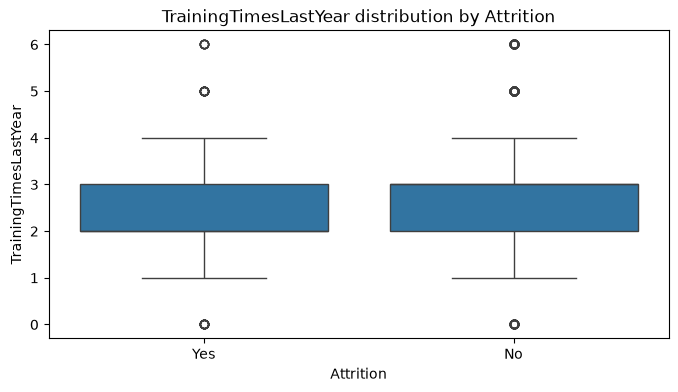

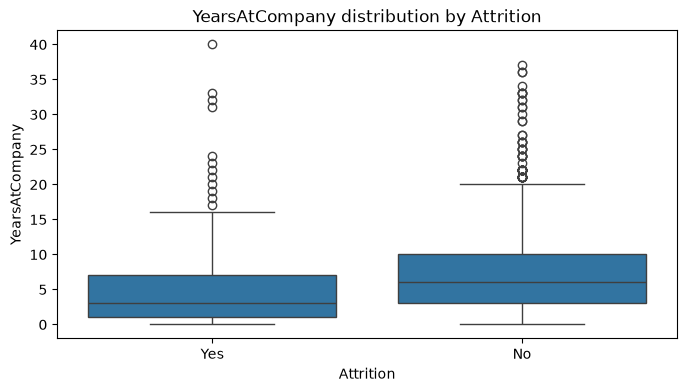

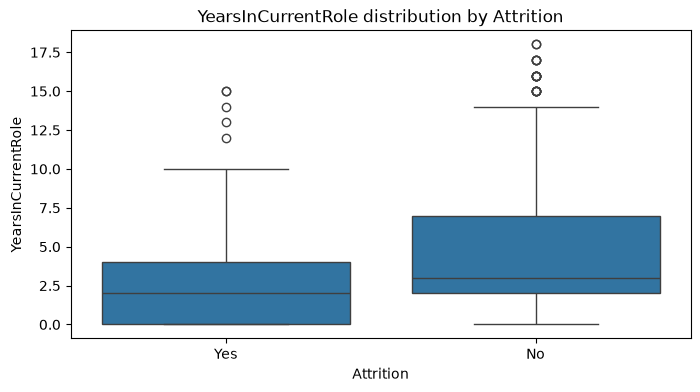

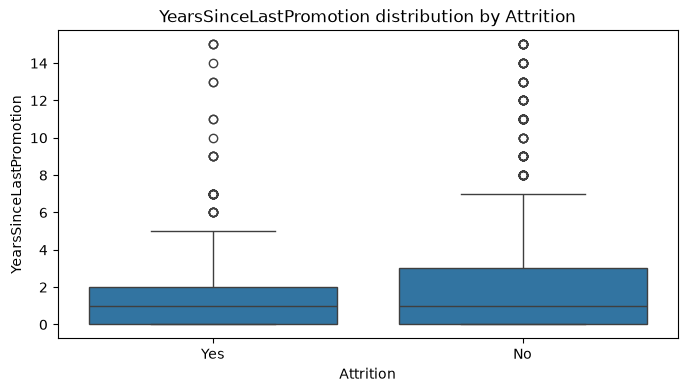

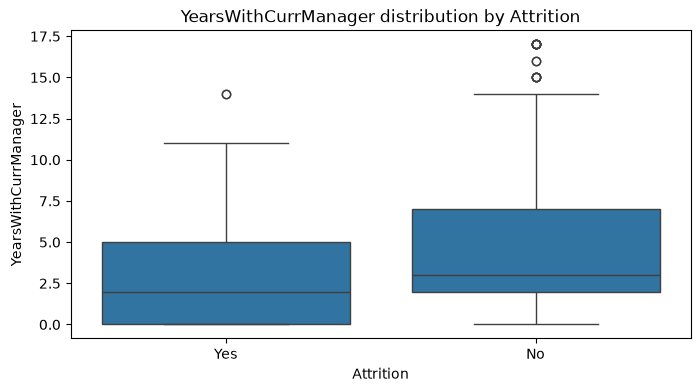

In [11]:

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Attrition', y=col, data=df)
    plt.title(f'{col} distribution by Attrition')
    plt.show()



### **Statistically Testing the Boxplot Inference**
boxplots shows how two groups look diffrent , but with an 84/16 imbalance, it can be misleading, that's why statistical tests are needed to confirm our findings.

**Steps for Statistical Test
- we use the **Mann-Whitney U test** - it checks whether the "left and "stayed group comes from diffrent distributions without assuming data is normally distributed, because most of columns are skewed.
- **p-value < 0.05** - the diffrence is probably real
- **p-value >0.05** - the diffrence we see is just random chance.
- we also check it with **group mean** side by side , because the diffrence can be statiscally real but very tiny and not much useful.

In [12]:
test_results = []
for col in num_cols:
    left = df[df["Attrition"] == "Yes"][col]
    stayed = df[df["Attrition"] == "No"][col]

    stat,p_value = mannwhitneyu(left,stayed,alternative="two-sided")

    test_results.append({
        "feature" : col,
        "mean_left" : round(left.mean(),2),
        "mean_stayed" : round(stayed.mean(),2),
        "p_value": round(p_value,5),
        "significance(p <0.05)" :p_value<0.05
    })

num_test_df =pd.DataFrame(test_results).sort_values("p_value")
num_test_df

,feature,mean_left,mean_stayed,p_value,significance(p <0.05)
0,Age,33.61,37.56,0.00000,True
4,MonthlyIncome,4787.09,6832.74,0.00000,True
9,TotalWorkingYears,8.24,11.86,0.00000,True
14,YearsWithCurrManager,2.85,4.37,0.00000,True
12,YearsInCurrentRole,2.90,4.48,0.00000,True
11,YearsAtCompany,5.13,7.37,0.00000,True
8,StockOptionLevel,0.53,0.85,0.00000,True
2,DistanceFromHome,10.63,8.92,0.00239,True
1,DailyRate,750.36,812.50,0.02900,True
13,YearsSinceLastPromotion,1.95,2.23,0.04118,True


## **Inferences from Bivariate Analysis**

### 1 `Age`, `MonthlyIncome`, `DailyRate`, `HourlyRate`, `MonthlyRate`, `PercentSalaryHike`
- **Age:** Employees who left (**Attriton = Yes**)are noticeabl-y younger, with lower mean age than employees who stayed. -  **confirmed significance (p<0.05)**
- **MonthlyIncome:** Employees who left have visibally lower income than ones who stayed **confirmed significance (p<0.05)**
- **DailyRate ,HourlyRate & MonthlyRate:** Distributions are almmost identical between two classes, with no meaningful diffrence by attrition. **significance (p>0.05)**
- **PercentsalaryHike:** both classes are nearly identical , do not correlate with attrition much. **significance (p>0.05)**


### 2 `TotalWorkingYears`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`, `YearsSinceLastPromotion`, `NumCompaniesWorked`
- **TotalWorkingYears:** Employees who left have less total working years-**confirmed significance (p<0.05)**
- **YearsAtCompany,YearsInCurrentRole &YearsWithCurrManager:** Employees who left have less time in current company current role or who have short tenure with current manager -**confirmed significance (p<0.05)**
- **YearsSinceLastPromotion:** both classes are hevily concentrated near 0-1 , not a strong diffrentiaternear - **not significant (p>0.05)**
- **NumCompaniesWorked:** classes largly overlap -**not significant (p>0.05)**

### 3 `DistanceFromHome`, `TrainingTimesLastYear`
- **DistanceFromHome:** Employees who left tends to live farther from office than those who stayed. significance value shows this is the weeakest feature in whole set. 
- **TrainingTimesLastYear** both classes have nearlly similar distribions **not significant (p>0.05)**

**Strong Predictive Features**
`MonthlyIncome`, `Age`, `TotalWorkingYears`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`

These show a real (p < 0.05) and practically meaningful gap in mean values between the two Attrition classes.

**Weak features**
`HourlyRate`, `MonthlyRate`, `PercentSalaryHike`, `TrainingTimesLastYear`, `YearsSinceLastPromotion`,`DistanceFromHome`
These do not show a statistically meaningful difference between classes.


### **Multicollinearity heatmap**
shows relationship between features

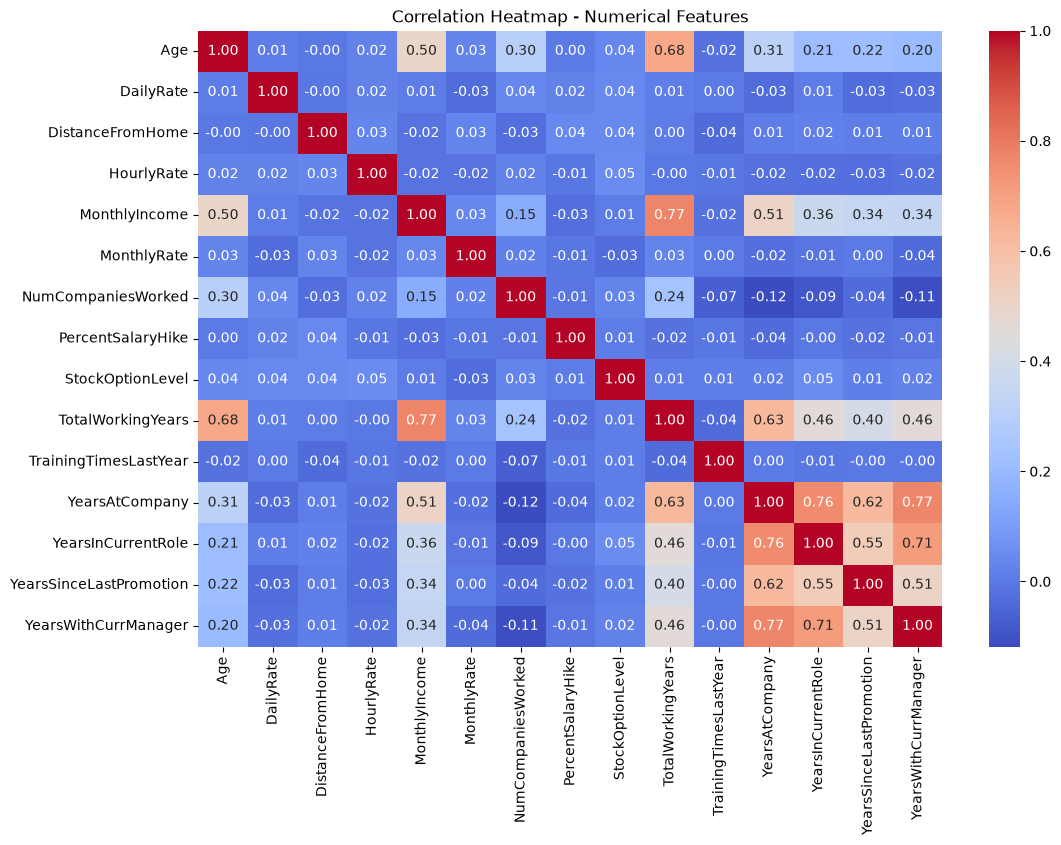

In [13]:
plt.figure(figsize= (12,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap - Numerical Features")
plt.show()

### **Inference**

- `YearsAtCompany`,` YearsInCurrentRole`,` YearsWithCurrManager `, & `YearsSinceLastPromotion` are strongly correlated to eachother. <br>
- `MonthlyIncome` is strongly correlated with `TotalWorkingYears` and moderatley with `Age` and `YearsAtCompany`
- `DailyRate`, `HourlyRate`, `MonthlyRate`, and `PercentSalaryHike` shows near zero correlation with other features, and with each other.
-  `DistanceFromHome` and `TrainingTimesLastYear` are isolated , both shows negligible correlation with every other numeric feature.
- `NumCompaniesWorked` has weak negative correlations with `YearsAtCompany` (-0.12), `YearsInCurrentRole` (-0.09), `YearsWithCurrManager` (-0.11) employees who have worked at more companies tend to have less tenure at current one.


### **Overall Inference**

`YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`, `YearsSinceLastPromotion`, `TotalWorkingYears` arre redundent with each other,which risks multicollinearity issues for linear models(Logistic Regression).

this shows linear won't be best fitted for this, but it doesn't concern tree based models.



### **Each feature's correlation with Attrition**

In [14]:
df['Attrition_num'] = df['Attrition'].map({'No':0, 'Yes':1})
attr_corr = df[num_cols + ['Attrition_num']].corr()['Attrition_num'].drop('Attrition_num').sort_values(ascending=False)
print(attr_corr)

DistanceFromHome           0.077924
NumCompaniesWorked         0.043494
MonthlyRate                0.015170
HourlyRate                -0.006846
PercentSalaryHike         -0.013478
YearsSinceLastPromotion   -0.033019
DailyRate                 -0.056652
TrainingTimesLastYear     -0.059478
YearsAtCompany            -0.134392
StockOptionLevel          -0.137145
YearsWithCurrManager      -0.156199
Age                       -0.159205
MonthlyIncome             -0.159840
YearsInCurrentRole        -0.160545
TotalWorkingYears         -0.171063
Name: Attrition_num, dtype: float64


.
### **Inference**
`TotalWorkingYears`, `YearsInCurrentRole`, `MonthlyIncome`, `Age`, `YearsWithCurrManager` all sit around -0.15 to -0.17, the strongest.

`DistanceFromHome` and `NumCompaniesWorked` sit near 0, confirming statisticals results obtained above.



## **Categorical features vs Attrition**

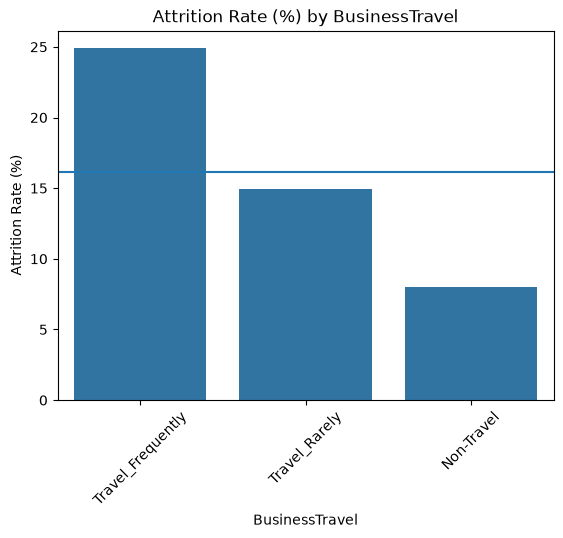

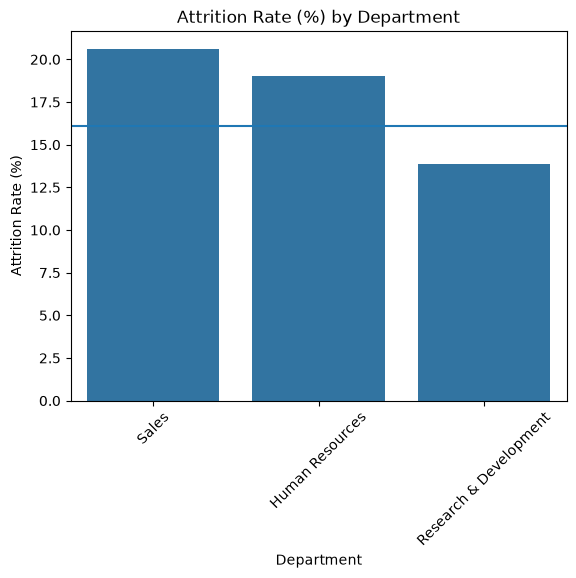

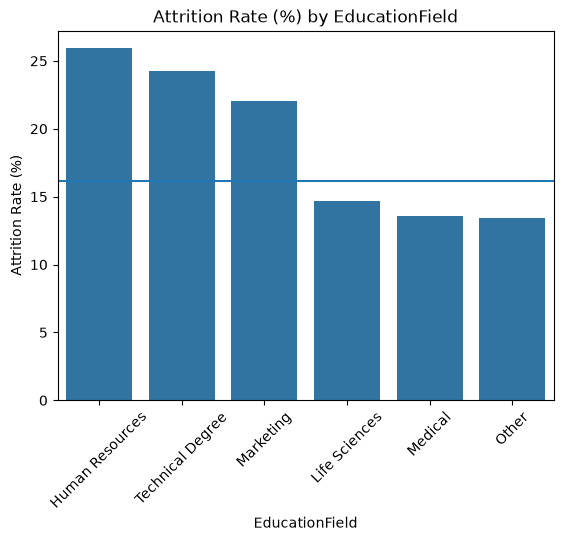

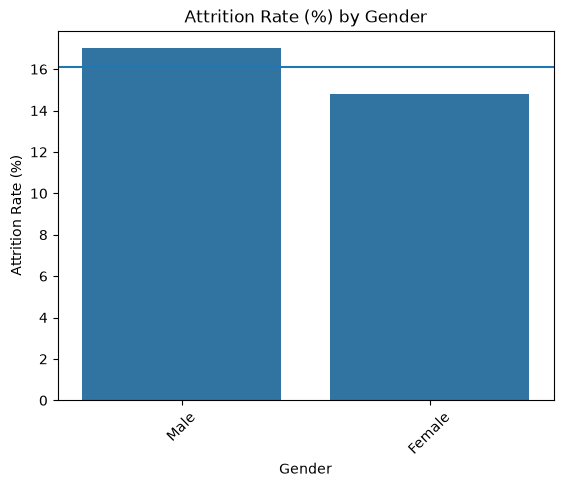

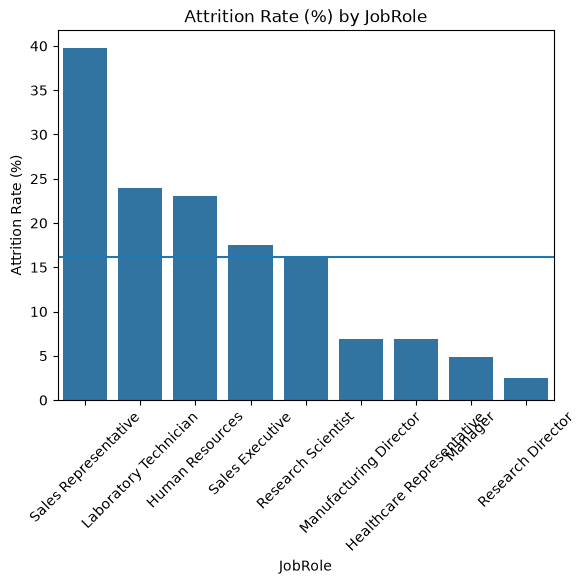

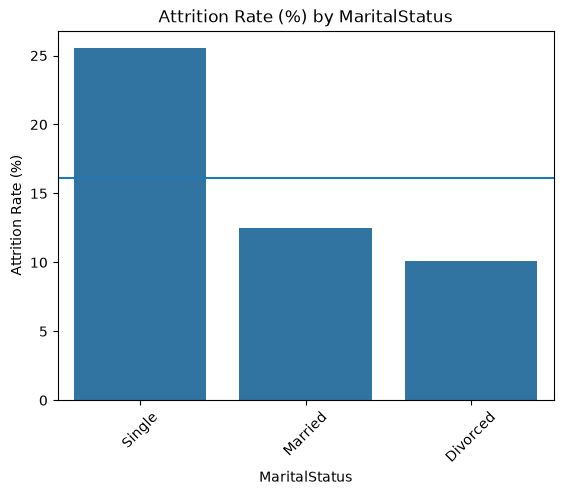

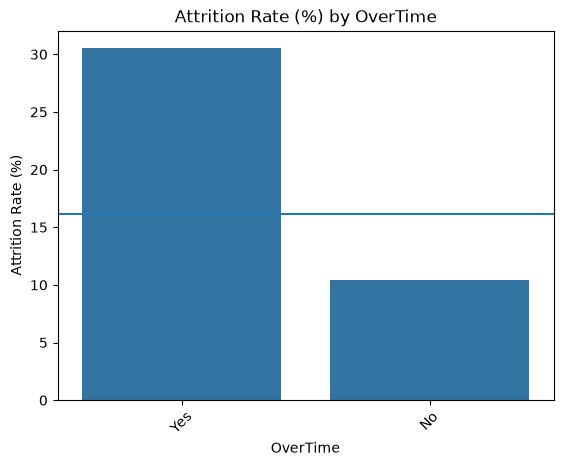

In [15]:

for col in cat_cols:
    if col == "Attrition":
        continue

    plt.Figure(figsize=(8,4))
    rate = df.groupby(col)["Attrition_num"].mean().sort_values(ascending=False)*100
    sns.barplot(x= rate.index ,y = rate.values)
    plt.title(f"Attrition Rate (%) by {col}")
    plt.ylabel("Attrition Rate (%)")
    plt.axhline(df["Attrition_num"].mean()*100)
    plt.xticks(rotation=45)
    plt.show()

### **Chi-squared test for each categorical feature**
this shows relationship visible in rate plots is stastically real and cramer's V tells us how strong it is.

Cramer's V: <0.1 = negligible, 0.1–0.3 = weak, 0.3–0.5 = moderate, >0.5 = strong.

In [16]:
def cramers_v (confusion_mat):
    chi2 = chi2_contingency(confusion_mat)[0]
    n = confusion_mat.sum().sum()
    r,k = confusion_mat.shape
    return np.sqrt(chi2/(n*(min(r,k) -1)))


cat_results = []
for col in cat_cols:
    if col == "Attrition":
        continue

    ct = pd.crosstab(df[col],df["Attrition"])
    chi2,p_value,dof,expected = chi2_contingency(ct)

    v = cramers_v(ct)
    cat_results.append({
        'feature': col,
        'p_value': round(p_value, 5),
        'cramers_v': round(v, 3),
        'significant (p<0.05)': p_value < 0.05
    })

cat_test_df = pd.DataFrame(cat_results).sort_values('cramers_v', ascending=False)
cat_test_df

,feature,p_value,cramers_v,significant (p<0.05)
6,OverTime,0.00000,0.244,True
4,JobRole,0.00000,0.242,True
5,MaritalStatus,0.00000,0.177,True
0,BusinessTravel,0.00001,0.128,True
2,EducationField,0.00677,0.104,True
1,Department,0.00453,0.086,True
3,Gender,0.29057,0.028,False


### **Inference from Categoriccal Analysis**

`OverTime` - Strongest categorical predictor. Employees who work overtime leave at higher rate than those who don't.

`JobRole`,`Department` - Attrition rate varies by role , roles like Laboratory Technician and Sales Representative shows higher attrition rate  while roles like Manager or Research Director shows lower attrition rate.

`MaritalStatus` single employees shows higher attrition rate compared to married ones.

`BusinessTravel` frequent travellers shows higher attrition rate.

`Gender` `EducationField` they are weak features for prediction.
 

## **Ordinal features vs Attrition**

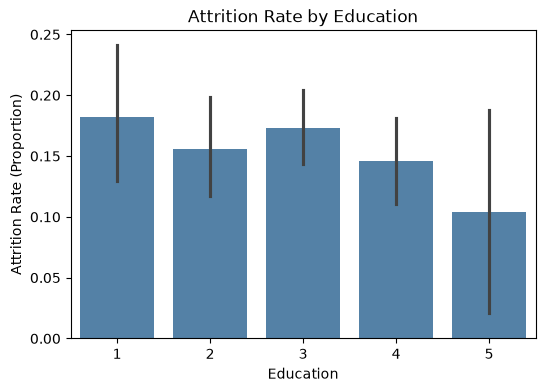

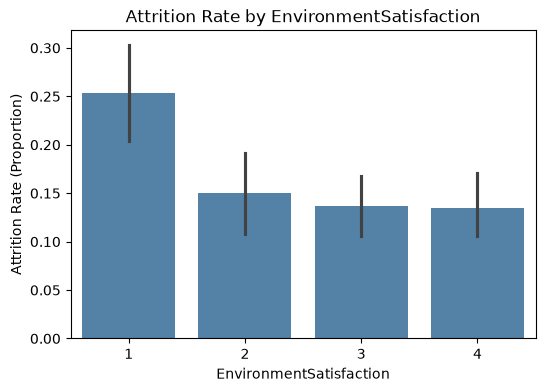

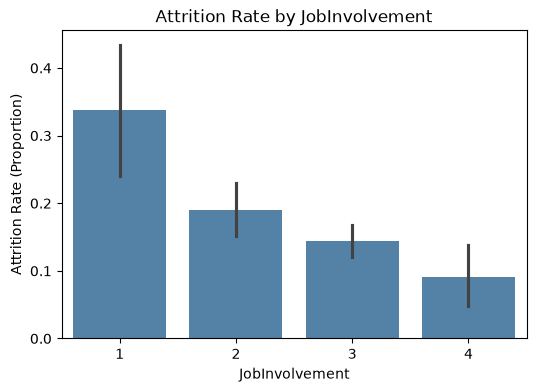

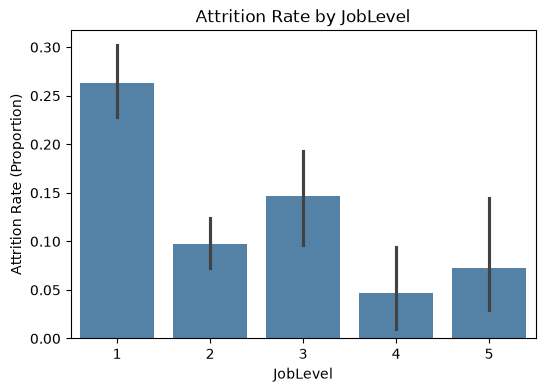

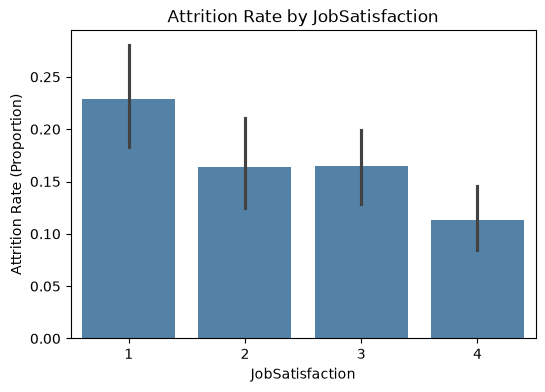

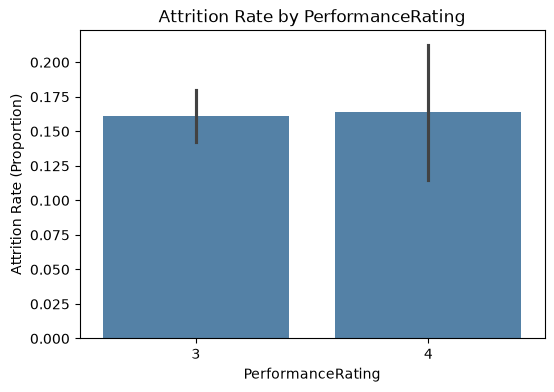

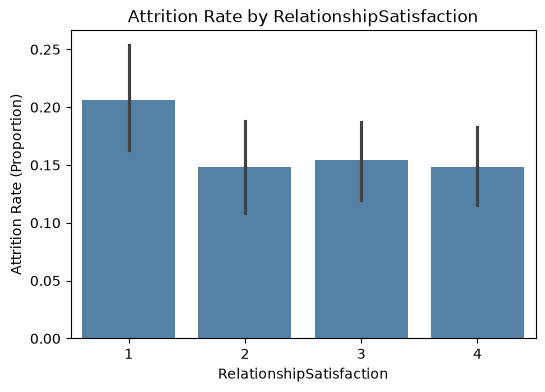

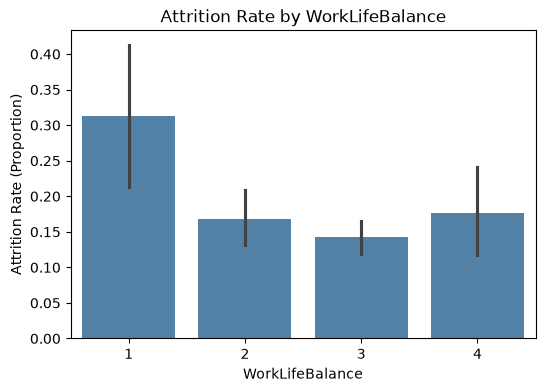

In [17]:
for col in ordinal_cols:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=df, x=col, y='Attrition_num', color='steelblue')
    
    plt.title(f'Attrition Rate by {col}')
    plt.ylabel('Attrition Rate (Proportion)')
    plt.xlabel(col)
    
    plt.show()

### **Spearman correlation for each Ordinal feature**

In [18]:
ordinal_results = []
for col in ordinal_cols:
    corr, p_value = spearmanr(df[col], df['Attrition_num'])
    ordinal_results.append({
        'feature': col,
        'spearman_corr': round(corr, 3),
        'p_value': round(p_value, 5),
        'significant (p<0.05)': p_value < 0.05
    })

ordinal_test_df = pd.DataFrame(ordinal_results).sort_values('p_value')
ordinal_test_df

,feature,spearman_corr,p_value,significant (p<0.05)
3,JobLevel,-0.190,0.00000,True
2,JobInvolvement,-0.119,0.00000,True
4,JobSatisfaction,-0.103,0.00008,True
1,EnvironmentSatisfaction,-0.096,0.00021,True
7,WorkLifeBalance,-0.052,0.04643,True
6,RelationshipSatisfaction,-0.043,0.10203,False
0,Education,-0.030,0.24493,False
5,PerformanceRating,0.003,0.91188,False


### **Inference**
- ordinal features with p < 0.05 (commonly `JobLevel`, `JobInvolvement`, `JobSatisfaction`, `EnvironmentSatisfaction`, `WorkLifeBalance` in this dataset) have a genuine, if modest, relationship with attrition: lower satisfaction/involvement/level scores tend to associate with higher attrition.



## **Final summary Statistically confirmed findings**
**Confirmed strong predictors of attrition:**
- Numeric: `MonthlyIncome`, `Age`, `TotalWorkingYears`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`
- Ordinal: whichever of `JobLevel`, `JobInvolvement`, `JobSatisfaction`, `EnvironmentSatisfaction`, `WorkLifeBalance` show p < 0.05 above
- Categorical: `OverTime` ( the strongest single feature)

**Confirmed weak / not predictive (despite sometimes looking different in raw plots):**
- `DistanceFromHome`, `NumCompaniesWorked`, `DailyRate`, `HourlyRate`, `MonthlyRate`, `PercentSalaryHike`, `TrainingTimesLastYear`, `YearsSinceLastPromotion`
